# NMF on Scotland-Only Corpus

**Purpose:** Train NMF on Scotland's corpus alone to discover what topics emerge when Scotland defines its own vocabulary — not measured through England's lens.

**Comparison:** England-only model (3,943 articles, k=30) vs Scotland-only model (511 articles, k=30)

**Key question:** Does Scotland's debate look different when it's not forced into England's topic structure?

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
from pathlib import Path
import logging
logging.basicConfig(level=logging.INFO)
logging.getLogger("gensim").setLevel(logging.WARNING)

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

from model_pipeline.training.s02_cleaning import run_cleaning
from model_pipeline.training.s03_spacy_processing import run_spacy_processing
from model_pipeline.training.s04_vectorisation import run_vectorisation
from model_pipeline.training.s05_nmf_training import run_nmf_training, get_top_words_per_topic
from model_pipeline.training.s06_topic_allocation import TOPIC_NAMES

## 1. Load Scotland data only

In [2]:
df_sco = pd.read_csv("../../data/training/sco_training.csv")
df_sco["country"] = "sco"
df_sco["text"] = df_sco["title"].fillna("") + "\n\n" + df_sco["text"].fillna("")
df_sco["date"] = pd.to_datetime(df_sco["article_date"], errors="coerce")

print(f"Scotland corpus: {len(df_sco)} articles")
print(f"By source:\n{df_sco['source'].value_counts()}")

Scotland corpus: 511 articles
By source:
source
gov_scot                188
children_in_scotland    182
gtcs                     67
ades                     50
sera                     24
Name: count, dtype: int64


## 2. Preprocessing

In [3]:
df_sco = run_cleaning(df_sco)
df_sco = run_spacy_processing(df_sco)
print(f"After preprocessing: {df_sco.shape}")
print(f"Empty text_final: {(df_sco['text_final'].str.len() == 0).sum()}")

INFO:model_pipeline.training.s02_cleaning:Step 02 (cleaning): starting. Input shape=(511, 14)
INFO:model_pipeline.training.s02_cleaning:Step 02 (cleaning): complete. Output shape=(511, 15)
INFO:model_pipeline.training.s02_cleaning:Empty cleaned texts: 0
INFO:model_pipeline.training.s03_spacy_processing:Step 03 (spacy): starting. Input shape=(511, 15)
INFO:model_pipeline.training.s03_spacy_processing:Loading spaCy model: en_core_web_sm
INFO:model_pipeline.training.s03_spacy_processing:spaCy processing complete (tokens_after_spacy created).
INFO:model_pipeline.training.s03_spacy_processing:Post-spaCy junk filtering complete (tokens_final + text_final created).
INFO:model_pipeline.training.s03_spacy_processing:Empty text_final rows: 0
INFO:model_pipeline.training.s03_spacy_processing:Step 03 (spacy): complete. Output shape=(511, 18)


After preprocessing: (511, 18)
Empty text_final: 0


## 3. Vectorise + train NMF
Same specs as England model: k=30, min_df=3, max_df=0.85, max_features=3000, ngram_range=(1,2)

**Note:** 511 articles with k=30 means ~17 articles per topic on average. Some topics may be very thin. Consider trying k=15 or k=20 as well.

In [4]:
vec_out = run_vectorisation(df_sco)
nmf_out = run_nmf_training(vec_out.X, n_topics=15, random_state=42, init="nndsvd", max_iter=1000)

print(f"TF-IDF matrix: {vec_out.X.shape}")
print(f"Vocabulary size: {len(vec_out.feature_names)}")
print(f"Reconstruction error: {nmf_out.reconstruction_error:.4f}")

INFO:model_pipeline.training.s04_vectorisation:Step 04 (vectorisation): starting. Input shape=(511, 18)
INFO:model_pipeline.training.s04_vectorisation:TF-IDF shape: (511, 3000)
INFO:model_pipeline.training.s04_vectorisation:Vectorizer params: min_df=3 max_df=0.85 max_features=3000 ngram_range=(1, 2)
INFO:model_pipeline.training.s04_vectorisation:Sample features: ['aberdeen', 'aberdeen city', 'aberdeenshire', 'aberlour', 'aberlour child', 'ability', 'able', 'absence', 'absence exclusion', 'absence school', 'abstract', 'abuse', 'abuse inquiry', 'aca', 'academic', 'academy', 'acceptable', 'access', 'access art', 'access education']
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): starting. X shape=(511, 3000)
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): complete.
INFO:model_pipeline.training.s05_nmf_training:W shape=(511, 15) | H shape=(15, 3000)
INFO:model_pipeline.training.s05_nmf_training:Reconstruction error: 19.958298


TF-IDF matrix: (511, 3000)
Vocabulary size: 3000
Reconstruction error: 19.9583


## 3b. Coherence sweep — find optimal k
Scotland has 511 articles. k=30 may be too many. Test k=5 to k=30.

INFO:model_pipeline.training.s07_evaluation:Coherence sweep: topic_range=[5, 10, 15, 20, 25, 30]
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=5
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=10
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=15
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=20
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=25
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=30


 n_topics  coherence_cv
        5      0.586106
       10      0.633617
       15      0.639723
       20      0.640700
       25      0.647233
       30      0.658644


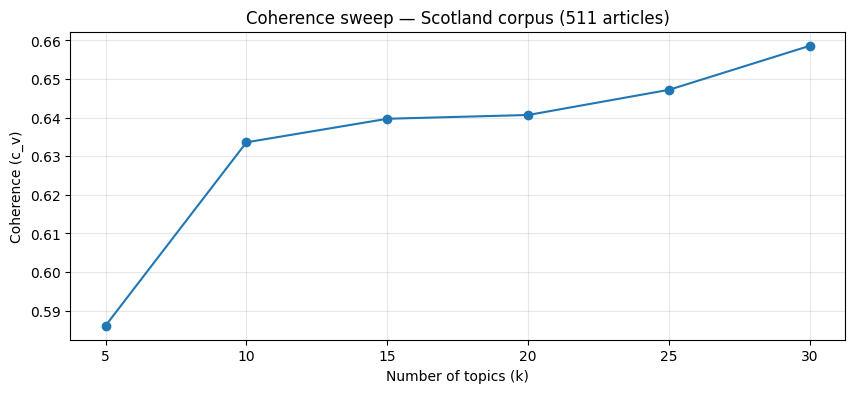


Best k: 30
Choose k based on coherence + interpretability. Update cell 3 if changing from k=30.


In [5]:
from model_pipeline.training.s07_evaluation import evaluate_coherence_over_topic_range
import matplotlib.pyplot as plt

texts_tokens = df_sco["tokens_final"].tolist()

df_coh = evaluate_coherence_over_topic_range(
    X=vec_out.X,
    feature_names=vec_out.feature_names,
    texts_tokens=texts_tokens,
    topic_range=range(5, 35, 5),
    n_top_words=10,
    random_state=42,
    init="nndsvd",
    max_iter=1000,
)

print(df_coh.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(df_coh["n_topics"], df_coh["coherence_cv"], marker="o")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence sweep — Scotland corpus (511 articles)")
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(range(5, 35, 5))[df_coh['coherence_cv'].argmax()]
print(f"\nBest k: {best_k}")
print("Choose k based on coherence + interpretability. Update cell 3 if changing from k=30.")


## 3c. Topic stability across random seeds

In [6]:
seeds = [42, 123, 456, 789, 1024]
H_matrices = []

for seed in seeds:
    model = NMF(n_components=nmf_out.nmf_model.n_components, init="nndsvda", random_state=seed, max_iter=1000)
    model.fit(vec_out.X)
    H_matrices.append(model.components_)
    print(f"Seed {seed}: recon error = {model.reconstruction_err_:.4f}")

pair_scores = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        sim = cosine_similarity(H_matrices[i], H_matrices[j])
        best_matches = sim.max(axis=1).mean()
        pair_scores.append(best_matches)
        print(f"Seeds {seeds[i]} vs {seeds[j]}: avg best-match = {best_matches:.4f}")

avg_stability = np.mean(pair_scores)
print(f"\nOverall topic stability: {avg_stability:.4f}")
print("Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable")


Seed 42: recon error = 19.9583
Seed 123: recon error = 19.9583
Seed 456: recon error = 19.9583
Seed 789: recon error = 19.9583
Seed 1024: recon error = 19.9583
Seeds 42 vs 123: avg best-match = 1.0000
Seeds 42 vs 456: avg best-match = 1.0000
Seeds 42 vs 789: avg best-match = 1.0000
Seeds 42 vs 1024: avg best-match = 1.0000
Seeds 123 vs 456: avg best-match = 1.0000
Seeds 123 vs 789: avg best-match = 1.0000
Seeds 123 vs 1024: avg best-match = 1.0000
Seeds 456 vs 789: avg best-match = 1.0000
Seeds 456 vs 1024: avg best-match = 1.0000
Seeds 789 vs 1024: avg best-match = 1.0000

Overall topic stability: 1.0000
Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable


## 4. Raw topic words

In [7]:
topics_sco = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=20)

print(f"{'Topic':>5}  Top 20 Words")
print("=" * 100)
for i, words in enumerate(topics_sco):
    print(f"{i:>5}  {', '.join(words)}")

Topic  Top 20 Words
    0  young, people, young people, child young, child, youth, work, group, support, person, community, young person, prevention, service, life, art, behaviour, project, advocacy, issue
    1  school, pupil, primary, primary school, attainment, library, behaviour, education, estate, staff, project, local, support, book, teacher, school pupil, ambassador, additional, funding, inclusion
    2  teacher, gtc, teaching, standard, profession, registration, professional, fitness, teaching profession, register, education, process, strategic, professional standard, council, teacher education, work, rule, regulation, role
    3  child, family, poverty, child poverty, sector, childcare, funding, parent, government, service, food, play, child family, uk, support, payment, charity, policy, life, community
    4  education, qualification, reform, bill, skill, body, national, system, education reform, learner, assessment, inspectorate, government, sqa, education bill, authority, i

## 5. Filtered top 30 words

In [8]:
display_stop = {
    "school", "education", "pupil", "student", "teacher", "year", "new", "work",
    "time", "say", "make", "good", "need", "use", "know", "want", "come", "take",
    "people", "government", "report", "system", "support", "include", "provide",
    "number", "change", "part", "set", "high", "low", "level", "national", "local",
    "public", "service", "also", "would", "could", "one", "two", "first", "last",
    "week", "month", "day", "told", "said", "according", "cent", "per", "per cent",
    "child", "children", "young", "staff", "area", "programme", "policy",
    "guidance", "framework", "response", "statement", "proposal", "approach",
    "review", "update", "document", "detail", "section", "datum", "figure",
    "survey", "rate", "score", "point", "proportion", "percentage",
    "organisation", "department", "committee", "institute", "foundation",
    "summit", "voice", "stakeholder", "partnership", "engagement",
    "scheme", "initiative", "pilot", "introduce", "implement", "launch",
    "office", "official", "notification", "recipient", "correspondence",
    "cookie", "banner", "subscribe", "contact", "submit", "accessibility",
    "share", "print", "visit", "site", "experience", "article", "news", "blog",
    "interesting", "fact", "previous", "current", "date", "information",
    "different", "large", "place", "individual", "view", "analysis",
    "thing", "way", "job"
}

topics_full = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=100)

print(f"{'Topic':>5}  Top 30 Words (display stopwords removed)")
print("=" * 140)
for i, words in enumerate(topics_full):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    print(f"{i:>5}  {', '.join(filtered)}")

Topic  Top 30 Words (display stopwords removed)
    0  young people, child young, youth, group, person, community, young person, prevention, life, art, behaviour, project, advocacy, issue, health, social, opportunity, world, member, creative, step, activity, harm, impact, access, lgbtq, resource, worker, mental, alcohol
    1  primary, primary school, attainment, library, behaviour, estate, project, book, school pupil, ambassador, additional, funding, inclusion, school library, secondary, secretary, inclusion ambassador, literacy, additional support, reading, attendance, building, council, education secretary, investment, gap, local authority, equity, attainment gap, learning
    2  gtc, teaching, standard, profession, registration, professional, fitness, teaching profession, register, process, strategic, professional standard, council, teacher education, rule, regulation, role, diversity, registrar, executive registrar, independent, trust, registration regulation, annual, dr pauline, 

## 6. LLM-assisted naming

In [9]:
import os
from pathlib import Path
from dotenv import load_dotenv
from anthropic import Anthropic
import json
import re

load_dotenv(Path("../../.env"))
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

topic_keyword_lines = []
for i, words in enumerate(topics_full):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    topic_keyword_lines.append(f"Topic {i}: {', '.join(filtered)}")

prompt = f"""You are helping label topics from an NMF topic model trained on Scottish education policy documents (2023-2025).
The corpus includes articles from Scottish Government, Children in Scotland, GTCS, ADES, and SERA.

For each topic below, suggest a short descriptive name (2-4 words, snake_case) based on the keywords, and explain in one sentence why you chose it.

{chr(10).join(topic_keyword_lines)}

Return ONLY a JSON list:
[
  {{"topic": 0, "suggested_name": "name", "explanation": "why"}},
  ...
]
No other text, no markdown, no code fences."""

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=4096,
    messages=[{"role": "user", "content": prompt}],
)

llm_text = response.content[0].text
cleaned = re.sub(r'^```(?:json)?\n?', '', llm_text.strip())
cleaned = re.sub(r'\n?```$', '', cleaned.strip())
llm_results = json.loads(cleaned)

print(f"{'Topic':>5}  {'LLM Suggestion':<35}  Explanation")
print("=" * 120)
for r in llm_results:
    print(f"{r['topic']:>5}  {r['suggested_name']:<35}  {r['explanation']}")

with open("../../data/evaluation_outputs/llm_scotland_topic_review.json", "w") as f:
    json.dump(llm_results, f, indent=2)

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Topic  LLM Suggestion                       Explanation
    0  youth_community_support              The keywords focus on young people, community engagement, prevention, and support services including mental health and advocacy.
    1  primary_attainment_gap               The keywords emphasize primary school education, attainment gaps, literacy, and inclusion initiatives with additional support measures.
    2  teaching_professional_standards      The keywords center on GTC registration, professional standards for teachers, and regulation of the teaching profession.
    3  child_poverty_families               The keywords focus on family support, child poverty, childcare funding, and community interventions for vulnerable families.
    4  education_system_reform              The keywords relate to qualification reform, education bills, assessment bodies like SQA, and systemic improvements in education.
    5  childrens_rights_uncrc               The keywords emphasize children's right

## 7. Finalise Scotland topic names

In [10]:
SCOTLAND_TOPIC_NAMES = {i: "TODO" for i in range(30)}

todos = [k for k, v in SCOTLAND_TOPIC_NAMES.items() if v == "TODO"]
if todos:
    print(f"WARNING: {len(todos)} topics still need naming")
else:
    print("All topics named.")

## 8. Topic distribution by source

In [11]:
df_sco["dominant_topic"] = nmf_out.W.argmax(axis=1)
df_sco["dominant_topic_weight"] = nmf_out.W.max(axis=1)

topic_counts = pd.Series(df_sco["dominant_topic"]).value_counts().sort_index()
print("Topic distribution:")
for t, n in topic_counts.items():
    name = SCOTLAND_TOPIC_NAMES.get(t, f'topic_{t}')
    print(f"  {name}: {n} ({n/len(df_sco)*100:.1f}%)")

print(f"\nDominant weight — mean: {df_sco['dominant_topic_weight'].mean():.4f}")

ct = pd.crosstab(df_sco['source'], df_sco['dominant_topic'], normalize='columns').round(2)
print("\nSource distribution per topic:")
print(ct)

Topic distribution:
  TODO: 67 (13.1%)
  TODO: 52 (10.2%)
  TODO: 60 (11.7%)
  TODO: 95 (18.6%)
  TODO: 39 (7.6%)
  TODO: 23 (4.5%)
  TODO: 17 (3.3%)
  TODO: 37 (7.2%)
  TODO: 9 (1.8%)
  TODO: 23 (4.5%)
  TODO: 11 (2.2%)
  TODO: 19 (3.7%)
  TODO: 21 (4.1%)
  TODO: 25 (4.9%)
  TODO: 13 (2.5%)

Dominant weight — mean: 0.1832

Source distribution per topic:
dominant_topic          0     1     2     3     4     5     6     7     8   \
source                                                                       
ades                  0.07  0.12  0.02  0.02  0.31  0.09  0.18  0.19  0.67   
children_in_scotland  0.79  0.23  0.02  0.68  0.08  0.61  0.12  0.22  0.00   
gov_scot              0.13  0.65  0.13  0.29  0.46  0.22  0.65  0.00  0.33   
gtcs                  0.00  0.00  0.82  0.00  0.13  0.09  0.06  0.03  0.00   
sera                  0.00  0.00  0.02  0.00  0.03  0.00  0.00  0.57  0.00   

dominant_topic          9     10    11    12    13    14  
source                               

## 9. Compare with England-only model
Which Scotland topics match England topics? Which are new?

In [12]:
import joblib

eng_nmf = joblib.load("../../experiments/outputs/runs/2026-03-20_135931/nmf_model.joblib")
eng_vec = joblib.load("../../experiments/outputs/runs/2026-03-20_135931/vectorizer.joblib")
eng_names = json.load(open("../../experiments/outputs/runs/2026-03-20_135931/topic_names.json"))
eng_features = eng_vec.get_feature_names_out()

eng_vocab = {w: i for i, w in enumerate(eng_features)}
sco_vocab = {w: i for i, w in enumerate(vec_out.feature_names)}
shared = sorted(set(eng_features) & set(vec_out.feature_names))

eng_H = np.zeros((30, len(shared)))
sco_H = np.zeros((30, len(shared)))
for j, word in enumerate(shared):
    eng_H[:, j] = eng_nmf.components_[:, eng_vocab[word]]
    sco_H[:, j] = nmf_out.H[:, sco_vocab[word]]

sim = cosine_similarity(sco_H, eng_H)

print(f"{'Scotland':>8}  {'Eng':>4}  {'Sim':>6}  {'Scotland Name':<30}  {'England Name':<30}")
print("=" * 110)
for sco_i in range(30):
    eng_i = sim[sco_i].argmax()
    s = sim[sco_i, eng_i]
    eng_name = eng_names.get(str(eng_i), eng_names.get(eng_i, '???'))
    sco_name = SCOTLAND_TOPIC_NAMES.get(sco_i, f'topic_{sco_i}')
    marker = '  ' if s > 0.8 else ' *' if s > 0.5 else '**'
    print(f"{sco_i:>8}  {eng_i:>4}  {s:.3f}{marker} {sco_name:<30}  {eng_name:<30}")

print(f"\nShared vocabulary: {len(shared)} / England: {len(eng_features)} / Scotland: {len(vec_out.feature_names)}")
print(f"Scotland-only words: {len(set(vec_out.feature_names) - set(eng_features))}")

ValueError: could not broadcast input array from shape (15,) into shape (30,)

## 10. Scotland-specific topics
Topics that don't match any England topic — these are what Scotland talks about that England's model can't see.

In [ ]:
print("SCOTLAND-SPECIFIC TOPICS (no strong England match):")
print("=" * 80)
for sco_i in range(30):
    best_sim = sim[sco_i].max()
    if best_sim < 0.5:
        sco_name = SCOTLAND_TOPIC_NAMES.get(sco_i, f'topic_{sco_i}')
        eng_i = sim[sco_i].argmax()
        eng_name = eng_names.get(str(eng_i), '???')
        print(f"\n{sco_name} (topic {sco_i}, best match: {eng_name} at {best_sim:.3f})")
        filtered = [w for w in topics_full[sco_i] if w not in display_stop and len(w) > 2][:20]
        print(f"  Keywords: {', '.join(filtered)}")
        source_breakdown = df_sco[df_sco['dominant_topic'] == sco_i]['source'].value_counts().to_dict()
        print(f"  Sources: {source_breakdown}")

## 11. Key findings

1. What topics does Scotland discover on its own terms that England's model can't see?
2. Which England topics have no Scottish equivalent?
3. Does Scotland's own model confirm 'mental health' and 'child welfare' as dominant — or was that an artefact of England's vocabulary?
4. What Scottish policy vocabulary enters the top 3,000 features that England's vocabulary excluded?

## 12. Save model artifacts
**Only run after finalising topic names.**

In [ ]:
import joblib
from datetime import datetime

run_id = "sco_" + datetime.now().strftime("%Y-%m-%d_%H%M%S")
run_dir = Path(f"../../experiments/outputs/runs/{run_id}")
run_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(nmf_out.nmf_model, run_dir / "nmf_model.joblib")
joblib.dump(vec_out.vectorizer, run_dir / "vectorizer.joblib")

with open(run_dir / "topic_names.json", "w") as f:
    json.dump(SCOTLAND_TOPIC_NAMES, f, indent=2)

metadata = {
    "run_id": run_id,
    "country": "scotland",
    "n_articles": len(df_sco),
    "n_topics": nmf_out.nmf_model.n_components,
    "reconstruction_error": float(nmf_out.reconstruction_error),
    "topic_stability": float(avg_stability),
    "corpus": "sco_training",
}
with open(run_dir / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {run_dir}")
print(f"Contents: {[f.name for f in run_dir.iterdir()]}")
